In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [3]:
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7565 non-null   object 
 1   district    7565 non-null   object 
 2   rooms       7565 non-null   int64  
 3   size        7564 non-null   float64
 4   level       7565 non-null   int64  
 5   max_levels  7565 non-null   int64  
 6   price       7466 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 413.8+ KB


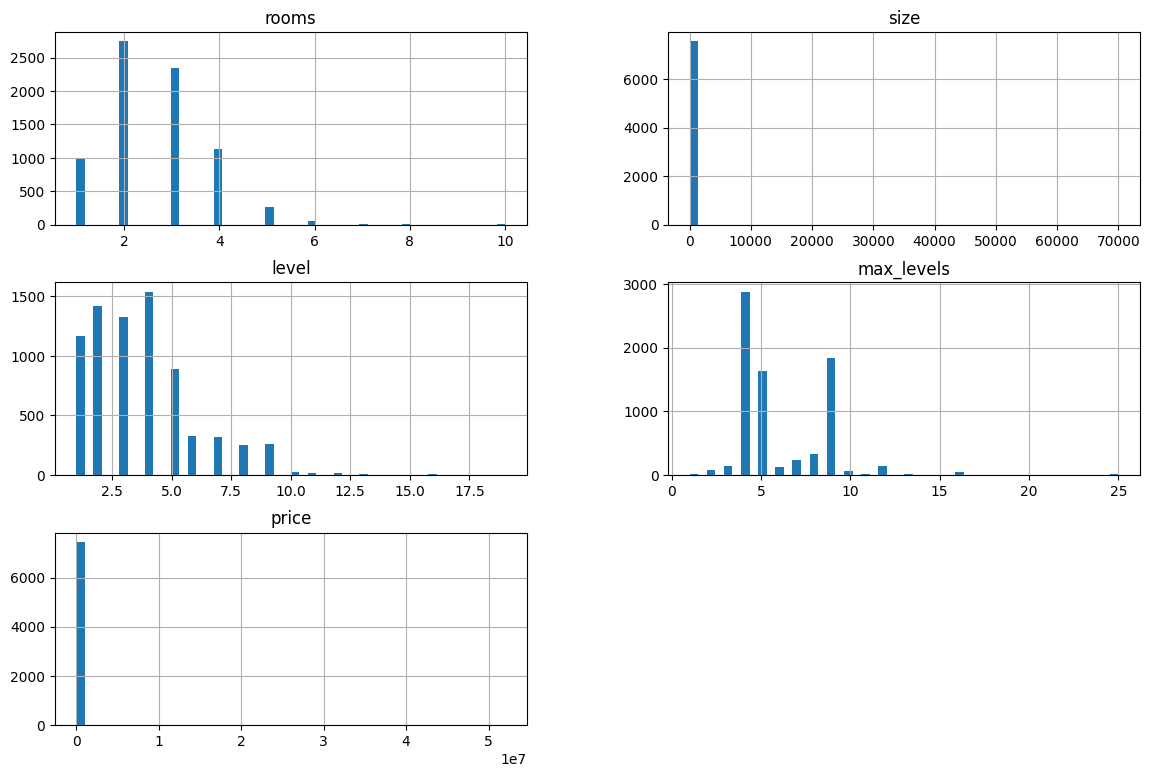

In [5]:
df.hist(bins=50, figsize=(14,9))
plt.show()

## As we can see we have Outliners, anomal values.
### lets clean our data

In [6]:
# Real bo'lishi mumkin bo'lgan chegaralarni belgilaymiz:
# Maydoni 15 kv.m dan kichik va 500 kv.m dan katta uylarni olib tashlaymiz
df_clean = df[(df['size'] >= 15) & (df['size'] <= 500)]

# Narxi juda arzon (masalan $5,000) yoki juda qimmat (masalan $1,000,000) uylarni cheklaymiz
df_clean = df_clean[(df_clean['price'] >= 5000) & (df_clean['price'] <= 1000000)]

# Qavat mantiqan jami qavatdan katta bo'lmasligi kerak
df_clean = df_clean[df_clean['level'] <= df_clean['max_levels']]

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7426 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7426 non-null   object 
 1   district    7426 non-null   object 
 2   rooms       7426 non-null   int64  
 3   size        7426 non-null   float64
 4   level       7426 non-null   int64  
 5   max_levels  7426 non-null   int64  
 6   price       7426 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 464.1+ KB


In [8]:
df_clean.count()

,0
location,7426
district,7426
rooms,7426
size,7426
level,7426
max_levels,7426
price,7426


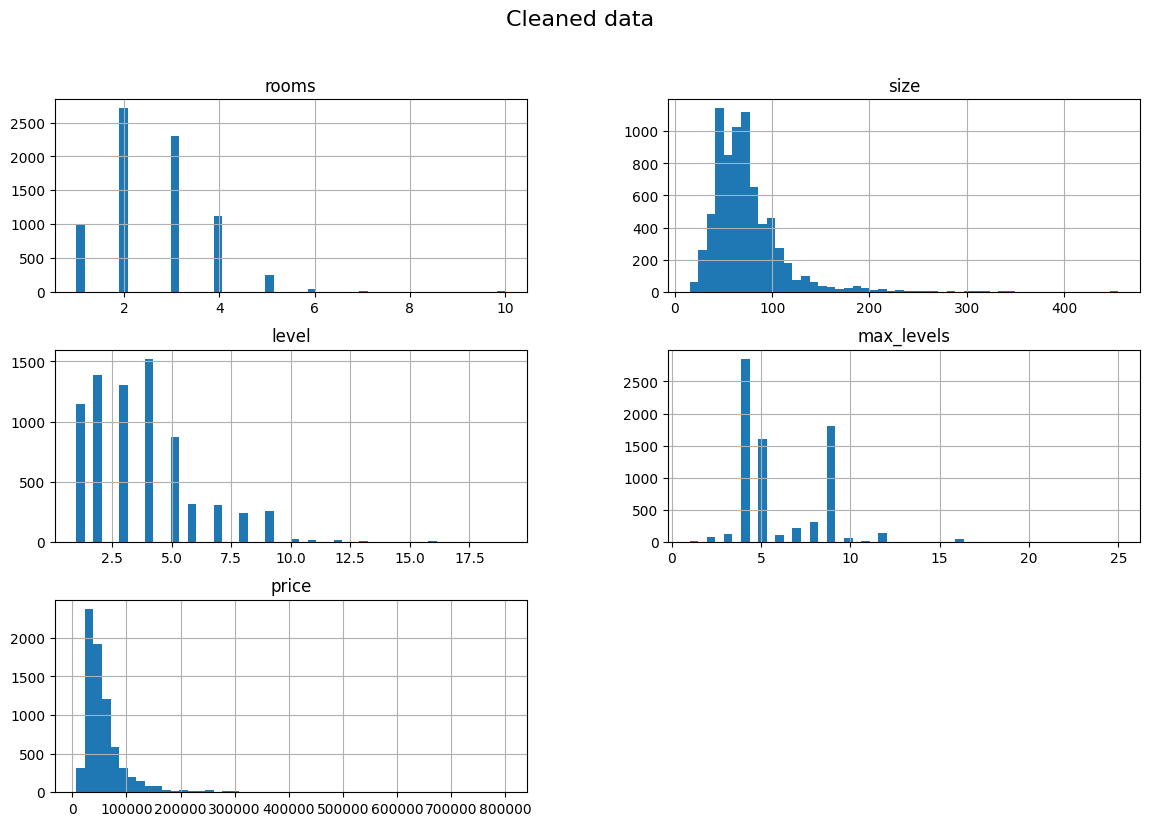

In [9]:
%matplotlib inline
df_clean.hist(bins=50, figsize=(14,9))
plt.suptitle('Cleaned data', fontsize=16)
plt.show()

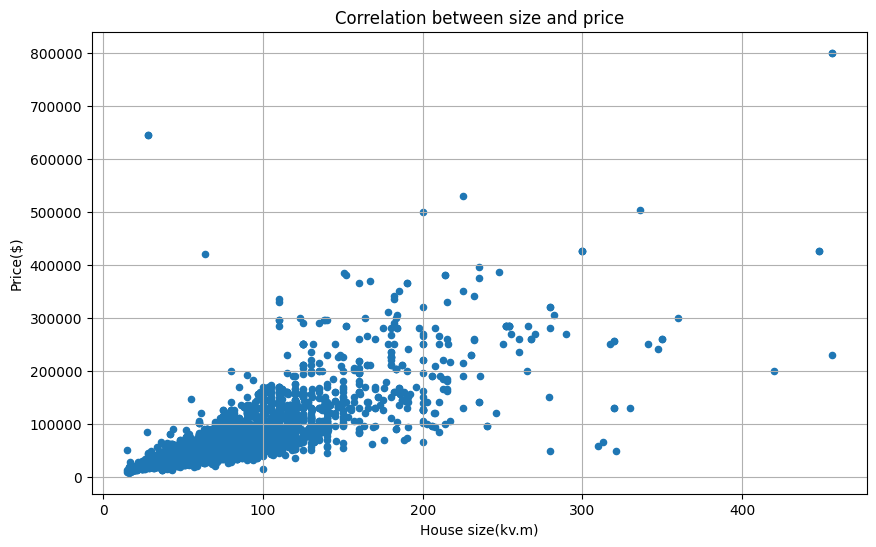

In [10]:
df_clean.plot(kind='scatter', x='size', y='price', alpha=1, figsize=(10,6))
plt.title('Correlation between size and price')
plt.xlabel('House size(kv.m)')
plt.ylabel('Price($)')
plt.grid(True)
plt.show()

## Checking the correlation

In [11]:
corr = df_clean[['rooms', 'size', 'level', 'max_levels', 'price']].corr()
print("Correlation with price:")
print(corr['price'].sort_values(ascending=False))

Correlation with price:
price         1.000000
size          0.781909
rooms         0.552782
max_levels    0.219815
level         0.059209
Name: price, dtype: float64


## We cleaned data.
## Next step saperating data to train and test.

In [12]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_clean, test_size=0.2, random_state=21)


X_train = train_set.drop('price', axis=1)
y_label = train_set['price'].copy()

In [13]:
# Numeric columns
num_attribs = ['rooms', 'size', 'level', 'max_levels']

# String (categorical) columns
cat_attribs = ['district'] # we took district instead of location because they both represent slmodt same thing

print("Columns successfully grouped")

Columns successfully grouped


## Numeric Pipeline

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('std', StandardScaler())
])

print("Numeric Pipeline is ready")

Numeric Pipeline is ready


## Full ColumnTransformer

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

print("Full Pipeline is ready")

Full Pipeline is ready


## Transformation

In [16]:
X_train_prepared = full_pipeline.fit_transform(X_train)

print(f"Not prepared data: {X_train.shape}")
print(f"Prepared data for ML: {X_train_prepared.shape}")

Not prepared data: (5940, 6)
Prepared data for ML: (5940, 16)


## Baseline Model - Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

LG_model = LinearRegression()

LG_model.fit(X_train_prepared, y_label)

LG_predictions = LG_model.predict(X_train_prepared)

LG_mse = mean_squared_error(y_label, LG_predictions)
LG_rmse = np.sqrt(LG_mse)

print(f"Linear Regression model RMSE: ${LG_rmse}")


Linear Regression model RMSE: $26582.97857559064


## We can see that our linear regression model is wrong for 26583


## Lets try something more complicated for example DecisionTreeRegressor
## Decision Tree Regressor model

In [18]:
from sklearn.tree import DecisionTreeRegressor

# 1. we are creating model
tree_model = DecisionTreeRegressor(random_state=42)

# 2. Teach model with prepared data
tree_model.fit(X_train_prepared, y_label)

# 3. Predicting
tree_predictions = tree_model.predict(X_train_prepared)

# 4. RMSE colculating erorr
tree_mse= mean_squared_error(y_label, tree_predictions)
tree_rmse = np.sqrt(tree_mse)

print(f"Decision Treee model RMSE: ${tree_rmse}")

Decision Treee model RMSE: $7013.260552500191


## As we can seee the RMSE is $7,013.26. At first glance it is very good output but this is bad beacause we have a hidden problem OVERFITTING

## Next step is checking the model Cross-Validation

In [20]:
from sklearn.model_selection import cross_val_score


scores = cross_val_score(tree_model, X_train_prepared, y_label, scoring="neg_mean_squared_error", cv=10)

tree_rmse_scores = np.sqrt(-scores)

print("10 ta qatlamning alohida xatoliklari:")

print(tree_rmse_scores)
print(f"\nRMSE: ${tree_rmse_scores.mean():2f}")
print(f"Standart Deviation: ${tree_rmse_scores.std():2f}")


10 ta qatlamning alohida xatoliklari:
[43246.48578173 21190.1850768  25865.32716944 21316.76550967
 28265.20384451 20371.83884582 28896.25870322 40292.63448887
 30053.90581832 38186.45674738]

RMSE: $29768.506199
Standart Deviation: $7841.740660


## Random Forest Regressor va uning Cross-Validation tahlili

In [21]:
from sklearn.ensemble import RandomForestRegressor

# 1. 100 ta daraxtdan iborat Random Forest modelini yaratamiz
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Modelni o'qitish (Fit)
forest_model.fit(X_train_prepared, y_label)

# 3. Uni ham qattiq nazorat (Cross-Validation) ostida tekshiramiz
forest_scores = cross_val_score(forest_model, X_train_prepared, y_label,
                                 scoring="neg_mean_squared_error", cv=10)

# 4. RMSE ko'rsatkichini hisoblash
forest_rmse_scores = np.sqrt(-forest_scores)

print(f"Random Forest Mean RMSE: ${forest_rmse_scores.mean():.2f}")
print(f"Random Forest Standard Deviation: ${forest_rmse_scores.std():.2f}")

Random Forest Mean RMSE: $24206.62
Random Forest Standard Deviation: $5433.91


In [22]:
X_test = test_set.drop("price", axis=1)
y_test = test_set['price'].copy()

X_test_prepared = full_pipeline.transform(X_test)

final_predictions = forest_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"Final test set RMSE: ${final_rmse:2f}")

Final test set RMSE: $21678.794553
